# Pipeline de Feature Engineering Hiérarchique — Prédiction Elo

- Bloc A — Temps intelligent
- Bloc B — Contexte fin de l'erreur
- Bloc C — Stabilité / cohérence

```
moves.csv  ──►  features move-level
                       │
                       ▼
               agrégation game-level  ◄──  games.csv
                       │
                       ▼
               agrégation player-level  ◄──  players.csv
                       │
                       ▼       
                 Modélisation     

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 0. Imports & Configuration

In [41]:
# — Google Colab uniquement — décommenter si nécessaire
# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, silhouette_score
)
from sklearn.metrics.pairwise import euclidean_distances

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost disponible")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost non disponible — pip install xgboost")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Chemins ────────────────────────────────────────────────
DATA_DIR     = Path('/content/drive/MyDrive/Data-PMIND-Final')
MOVES_PATH   = DATA_DIR / 'moves.csv'
GAMES_PATH   = DATA_DIR / 'games.csv'
SUMMARY_PATH = DATA_DIR / 'summary.csv'
PLAYERS_PATH = DATA_DIR / 'players.csv'

RANDOM_STATE = 42

# ── Seuils partagés (documentation centralisée) ───────────────────────────────
EVAL_CAP        = 900    # cp — au-delà : mat détecté, on plafonne
LOSS_CAP        = 600    # cp — cap blunder sévère
THRESHOLD_WIN   = 150    # cp — position gagnante si eval_pour_joueur > 150
THRESHOLD_LOSE  = -150   # cp — position perdante si eval_pour_joueur < -150
LOW_CLOCK_RATIO = 0.20   # proportion de l'horloge initiale = "faible temps"

print("✓ Imports OK")
print(f"  Seuils : EVAL_CAP={EVAL_CAP}, LOSS_CAP={LOSS_CAP}, "
      f"WIN>{THRESHOLD_WIN}, LOSE<{THRESHOLD_LOSE}, LOW_CLOCK<{LOW_CLOCK_RATIO*100:.0f}%")

✓ XGBoost disponible
✓ Imports OK
  Seuils : EVAL_CAP=900, LOSS_CAP=600, WIN>150, LOSE<-150, LOW_CLOCK<20%


---
## 1. Chargement & Inspection

moves   : 1,628,149 lignes × 23 colonnes
games   :   25,848 lignes × 23 colonnes
summary :   25,848 lignes × 21 colonnes
players :      941 lignes × 12 colonnes

Joueurs : 941 dans games, 941 dans players


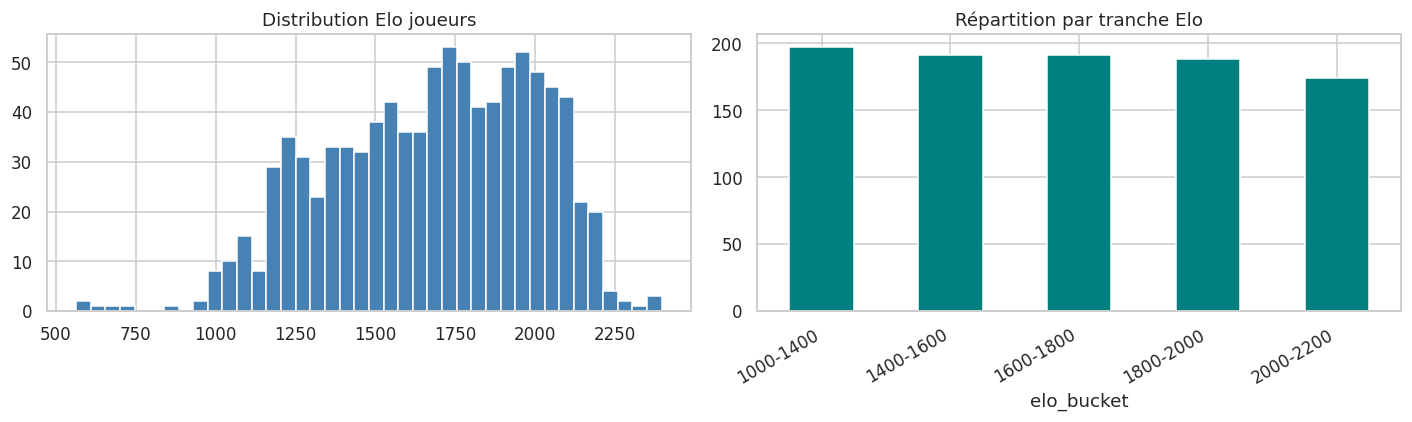

In [25]:
def load_data(moves_path, games_path, summary_path, players_path):
    moves   = pd.read_csv(moves_path)
    games   = pd.read_csv(games_path)
    summary = pd.read_csv(summary_path)
    players = pd.read_csv(players_path)
    print(f"moves   : {moves.shape[0]:>8,} lignes × {moves.shape[1]} colonnes")
    print(f"games   : {games.shape[0]:>8,} lignes × {games.shape[1]} colonnes")
    print(f"summary : {summary.shape[0]:>8,} lignes × {summary.shape[1]} colonnes")
    print(f"players : {players.shape[0]:>8,} lignes × {players.shape[1]} colonnes")
    print(f"\nJoueurs : {games['target_name'].nunique()} dans games, "
          f"{players['username'].nunique()} dans players")
    return moves, games, summary, players

moves, games, summary, players = load_data(
    MOVES_PATH, GAMES_PATH, SUMMARY_PATH, PLAYERS_PATH
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
players['elo'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution Elo joueurs')
players['elo_bucket'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Répartition par tranche Elo')
plt.tight_layout(); plt.show()

---
## 2. Nettoyage des Moves

### Hypothèses documentées
| Variable | Traitement | Justification |
|---|---|---|
| `eval_white_before/after` > ±900 | Clamp à ±900 | Mats détectés codés ±9999 non comparables aux pertes en cp |
| `loss_signed` < 0 | Clip à 0 | Coup légèrement meilleur que le moteur bruit numérique |
| `loss_signed` > 600 | Clip à 600 | Mat dans le coup : on plafonne pour ne pas fausser les moyennes |
| `time_spent_cs` null | Remplacé par 0 | Coups ultra-rapides (bullet / premove) — absence = vitesse extrême |
| `clock_before_cs` null (~269 coups) | Médiane de la colonne | Données manquantes isolées |

In [42]:
def clean_moves(moves: pd.DataFrame) -> pd.DataFrame:
    """Nettoyage et feature engineering au niveau coup."""
    df = moves.copy()

    # ── 0. Diagnostic valeurs manquantes / nulles sur le temps ───────────────
    n_time_spent_missing = df['time_spent_cs'].isna().sum()
    n_time_spent_zero_raw = df['time_spent_cs'].fillna(-999).eq(0).sum()
    n_clock_missing = df['clock_before_cs'].isna().sum()
    n_clock_zero_raw = df['clock_before_cs'].fillna(-999).eq(0).sum()

    # ── 1. Clamp des évals (mats → ±9999) ────────────────────────────────────
    df['eval_before_capped'] = df['eval_white_before'].clip(-EVAL_CAP, EVAL_CAP)
    df['eval_after_capped']  = df['eval_white_after'].clip(-EVAL_CAP, EVAL_CAP)

    # ── 2. Perte réelle du point de vue du joueur ─────────────────────────────
    # L'éval moteur est toujours du côté Blanc → inverser pour les Noirs
    df['loss_signed'] = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'] - df['eval_after_capped'],
        df['eval_after_capped']  - df['eval_before_capped']
    )
    df['loss_capped'] = df['loss_signed'].clip(0, LOSS_CAP)
    df['loss_log']    = np.log1p(df['loss_capped'])

    # cp_loss fourni dans les données (nettoyage)
    df['cp_loss_clean'] = df['cp_loss'].abs().clip(0, LOSS_CAP)

    # ── 3. Contexte positionnel ───────────────────────────────────────────────
    df['eval_abs'] = df['eval_before_capped'].abs()
    eval_for_player = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'],
        -df['eval_before_capped']
    )
    df['is_winning'] = (eval_for_player > THRESHOLD_WIN).astype(int)
    df['is_equal']   = ((eval_for_player >= THRESHOLD_LOSE) &
                        (eval_for_player <= THRESHOLD_WIN)).astype(int)
    df['is_losing']  = (eval_for_player < THRESHOLD_LOSE).astype(int)

    # ── 4. Taxonomie Lichess ──────────────────────────────────────────────────
    # Seuils : good<50 | inaccuracy 50-100 | mistake 100-200 | blunder≥200
    df['is_good']       = (df['loss_capped'] < 50).astype(int)
    df['is_inaccuracy'] = ((df['loss_capped'] >= 50) & (df['loss_capped'] < 100)).astype(int)
    df['is_mistake']    = ((df['loss_capped'] >= 100) & (df['loss_capped'] < 200)).astype(int)
    df['is_blunder']    = (df['loss_capped'] >= 200).astype(int)
    df['is_error']      = (df['loss_capped'] >= 50).astype(int)

    # NaN pour les coups adverses (pas de cp_loss calculable)
    mask_not_target = ~df['is_target_move']
    for col in ['is_good', 'is_inaccuracy', 'is_mistake', 'is_blunder', 'is_error',
                'loss_capped', 'loss_log', 'cp_loss_clean']:
        df.loc[mask_not_target, col] = np.nan

    # ── 5. Phase encodée ──────────────────────────────────────────────────────
    df['is_opening']    = (df['phase'] == 'opening').astype(int)
    df['is_middlegame'] = (df['phase'] == 'middlegame').astype(int)
    df['is_endgame']    = (df['phase'] == 'endgame').astype(int)

    # ── 6. Temps ──────────────────────────────────────────────────────────────
    df['time_spent_s'] = df['time_spent_cs'].fillna(0) / 100
    df['clock_s']      = df['clock_before_cs'].fillna(
        df['clock_before_cs'].median()
    ) / 100
    df['time_log'] = np.log1p(df['time_spent_s'])

    # Diagnostics après imputation
    n_time_spent_zero_after = (df['time_spent_s'] == 0).sum()
    n_clock_zero_after = (df['clock_s'] == 0).sum()

    # ── 7. Type de coup ───────────────────────────────────────────────────────
    df['is_capture']   = df['is_capture'].astype(int)
    df['is_check']     = df['is_check'].astype(int)
    df['is_castle']    = df['is_castle'].astype(int)
    df['is_promotion'] = df['is_promotion'].astype(int)
    df['move_number']  = (df['ply'] + 1) // 2

    print(f"✓ Moves nettoyés : {len(df):,} lignes, {len(df.columns)} colonnes")
    tgt = df[df['is_target_move']]
    print(f"  Coups du joueur cible : {len(tgt):,}")

    print("\n--- Diagnostic temps ---")
    print(f"time_spent_cs manquants avant imputation : {n_time_spent_missing:,}")
    print(f"time_spent_cs == 0 avant imputation      : {n_time_spent_zero_raw:,}")
    print(f"time_spent_s == 0 après imputation       : {n_time_spent_zero_after:,}")

    print(f"clock_before_cs manquants avant imputation : {n_clock_missing:,}")
    print(f"clock_before_cs == 0 avant imputation      : {n_clock_zero_raw:,}")
    print(f"clock_s == 0 après imputation              : {n_clock_zero_after:,}")

    return df

moves_clean = clean_moves(moves)

✓ Moves nettoyés : 1,628,149 lignes, 45 colonnes
  Coups du joueur cible : 814,042

--- Diagnostic temps ---
time_spent_cs manquants avant imputation : 895
time_spent_cs == 0 avant imputation      : 241,892
time_spent_s == 0 après imputation       : 242,787
clock_before_cs manquants avant imputation : 895
clock_before_cs == 0 avant imputation      : 198
clock_s == 0 après imputation              : 198


---
## 2b. Diagnostic — Comparaison des Mesures de Perte

> On compare `loss_capped` (calculé depuis les évals moteur) et `cp_loss_clean` (fourni directement dans les données). L'objectif est de valider quelle version utiliser pour les features.

COMPARAISON loss_capped vs cp_loss_clean

--- loss_capped (reconstruit depuis eval moteur) ---
count   814042.000
mean         2.060
std          8.200
min          0.000
25%          0.000
50%          0.000
75%          0.000
max        600.000
Name: loss_capped, dtype: float64

--- cp_loss_clean (fourni dans les données, abs+clip) ---
count   814042.000
mean        73.040
std        132.570
min          0.000
25%          6.000
50%         20.000
75%         69.000
max        600.000
Name: cp_loss_clean, dtype: float64

--- Taux catégories avec loss_capped ---
  good        : 99.6%
  inaccuracy  : 0.3%
  mistake     : 0.1%
  blunder     : 0.0%

--- Taux catégories avec cp_loss_clean ---
  good        : 68.7%
  inaccuracy  : 12.5%
  mistake     : 8.8%
  blunder     : 10.1%

Corrélation Pearson : -0.058
Différence absolue médiane : 17.0 cp


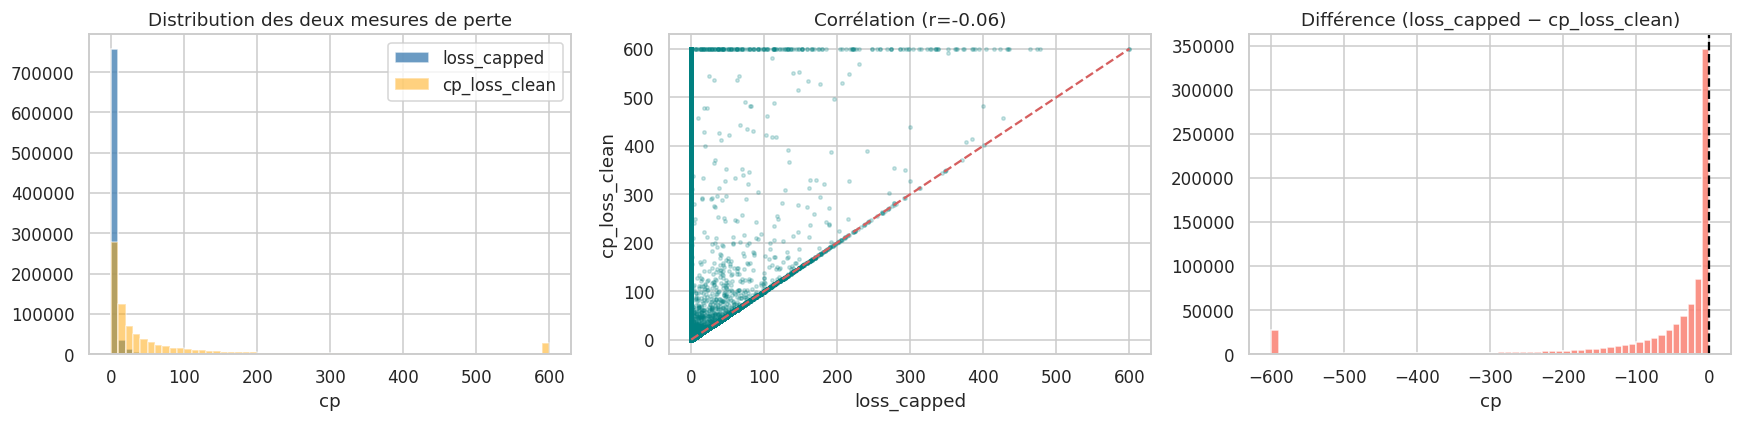


CONCLUSION AUTOMATIQUE
► CONCLUSION : on utilise cp_loss_clean pour les features de perte et de qualité de coup.
  Justification :
  - loss_capped apparaît anormalement concentrée sur 0,
  - la taxonomie d'erreurs issue de loss_capped est peu réaliste,
  - la corrélation entre les deux mesures est trop faible pour valider loss_capped.
  → loss_capped est conservée seulement comme variable de diagnostic.


In [43]:
tgt = moves_clean[moves_clean['is_target_move']].copy()

print("=" * 60)
print("COMPARAISON loss_capped vs cp_loss_clean")
print("=" * 60)

print("\n--- loss_capped (reconstruit depuis eval moteur) ---")
print(tgt['loss_capped'].describe().round(2))

print("\n--- cp_loss_clean (fourni dans les données, abs+clip) ---")
print(tgt['cp_loss_clean'].describe().round(2))

# Taux de catégories avec chaque mesure
print("\n--- Taux catégories avec loss_capped ---")
loss_rates = {}
for label, lo, hi in [('good', 0, 49), ('inaccuracy', 50, 99), ('mistake', 100, 199), ('blunder', 200, 600)]:
    rate = ((tgt['loss_capped'] >= lo) & (tgt['loss_capped'] <= hi)).mean()
    loss_rates[label] = rate
    print(f"  {label:12s}: {rate*100:.1f}%")

print("\n--- Taux catégories avec cp_loss_clean ---")
cp = tgt['cp_loss_clean'].dropna()
cp_rates = {}
for label, lo, hi in [('good', 0, 49), ('inaccuracy', 50, 99), ('mistake', 100, 199), ('blunder', 200, 600)]:
    rate = ((cp >= lo) & (cp <= hi)).mean()
    cp_rates[label] = rate
    print(f"  {label:12s}: {rate*100:.1f}%")

# Corrélation entre les deux
valid = tgt[['loss_capped', 'cp_loss_clean']].dropna()
corr = valid.corr().iloc[0, 1]
median_abs_diff = (valid['loss_capped'] - valid['cp_loss_clean']).abs().median()

print(f"\nCorrélation Pearson : {corr:.3f}")
print(f"Différence absolue médiane : {median_abs_diff:.1f} cp")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(tgt['loss_capped'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8, label='loss_capped')
axes[0].hist(tgt['cp_loss_clean'].dropna(), bins=60, color='orange', edgecolor='white', alpha=0.5, label='cp_loss_clean')
axes[0].set_title('Distribution des deux mesures de perte')
axes[0].set_xlabel('cp')
axes[0].legend()

axes[1].scatter(valid['loss_capped'], valid['cp_loss_clean'], alpha=0.2, s=5, color='teal')
mn, mx = 0, 600
axes[1].plot([mn, mx], [mn, mx], '--r', lw=1.5)
axes[1].set_xlabel('loss_capped')
axes[1].set_ylabel('cp_loss_clean')
axes[1].set_title(f'Corrélation (r={corr:.2f})')

diff = valid['loss_capped'] - valid['cp_loss_clean']
axes[2].hist(diff, bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='black', lw=1.5, linestyle='--')
axes[2].set_title('Différence (loss_capped − cp_loss_clean)')
axes[2].set_xlabel('cp')

plt.tight_layout()
plt.show()

# ============================================================
# Conclusion automatique
# ============================================================

loss_median = tgt['loss_capped'].median()
loss_p75 = tgt['loss_capped'].quantile(0.75)
loss_good_rate = loss_rates['good']
cp_good_rate = cp_rates['good']

use_cp_loss = (
    corr < 0.30 or
    loss_good_rate > 0.95 or
    loss_median == 0 or
    loss_p75 == 0
)

print("\n" + "=" * 60)
print("CONCLUSION AUTOMATIQUE")
print("=" * 60)

if use_cp_loss:
    print("► CONCLUSION : on utilise cp_loss_clean pour les features de perte et de qualité de coup.")
    print("  Justification :")
    print("  - loss_capped apparaît anormalement concentrée sur 0,")
    print("  - la taxonomie d'erreurs issue de loss_capped est peu réaliste,")
    print("  - la corrélation entre les deux mesures est trop faible pour valider loss_capped.")
    print("  → loss_capped est conservée seulement comme variable de diagnostic.")
else:
    print("► CONCLUSION : on peut utiliser loss_capped pour les features.")
    print("  Justification :")
    print("  - distribution cohérente,")
    print("  - taxonomie d'erreurs plausible,")
    print("  - corrélation suffisante avec cp_loss_clean.")

---
## 3. Agrégation Game-Level

On intègre ici toutes les nouvelles features des **Blocs A, B, C** en plus des features existantes.

In [44]:
def compute_low_clock_threshold(game_id, m):
    """
    Pour chaque partie, la pression temporelle est définie comme :
    clock_s < LOW_CLOCK_RATIO * clock_max_de_la_partie
    Retourne un masque booléen.
    """
    max_clock = m.groupby('game_id')['clock_s'].transform('max')
    return (m['clock_s'] < LOW_CLOCK_RATIO * max_clock).astype(int)


def build_game_features(moves_clean: pd.DataFrame) -> pd.DataFrame:
    """Agrège les features move-level au niveau partie en utilisant cp_loss_clean."""

    m = moves_clean[moves_clean['is_target_move']].copy()

    # ── Mesure principale de perte ─────────────────────────────────────
    m['loss_main'] = m['cp_loss_clean']
    m['loss_log_main'] = np.log1p(m['loss_main'])

    # ── Masque de pression temporelle (local à la partie) ──────────────
    max_clock_per_game = m.groupby('game_id')['clock_s'].transform('max')
    m['is_low_clock'] = (m['clock_s'] < LOW_CLOCK_RATIO * max_clock_per_game).astype(int)

    # ── Coup critique = erreur OU position complexe ────────────────────
    m['is_critical'] = ((m['is_error'] == 1) | (m['eval_abs'] > 300)).astype(int)

    agg = {}

    # ═══════════════════════════════════════════════════════════════════
    # FEATURES EXISTANTES (corrigées avec cp_loss_clean)
    # ═══════════════════════════════════════════════════════════════════
    agg['n_moves']         = ('loss_main', 'count')
    agg['loss_mean']       = ('loss_main', 'mean')
    agg['loss_median']     = ('loss_main', 'median')
    agg['loss_std']        = ('loss_main', 'std')
    agg['loss_p90']        = ('loss_main', lambda x: x.quantile(0.90))
    agg['loss_max']        = ('loss_main', 'max')
    agg['loss_log_mean']   = ('loss_log_main', 'mean')

    agg['rate_good']       = ('is_good', 'mean')
    agg['rate_inaccuracy'] = ('is_inaccuracy', 'mean')
    agg['rate_mistake']    = ('is_mistake', 'mean')
    agg['rate_blunder']    = ('is_blunder', 'mean')
    agg['rate_error']      = ('is_error', 'mean')
    agg['n_blunders']      = ('is_blunder', 'sum')
    agg['n_mistakes']      = ('is_mistake', 'sum')

    agg['rate_loss_gt100'] = ('loss_main', lambda x: (x > 100).mean())
    agg['rate_loss_gt200'] = ('loss_main', lambda x: (x > 200).mean())

    agg['time_mean_s']     = ('time_spent_s', 'mean')
    agg['time_median_s']   = ('time_spent_s', 'median')
    agg['time_std_s']      = ('time_spent_s', 'std')
    agg['time_max_s']      = ('time_spent_s', 'max')
    agg['time_log_mean']   = ('time_log', 'mean')
    agg['clock_mean_s']    = ('clock_s', 'mean')

    agg['time_mean_on_error'] = (
        'time_spent_s',
        lambda x: x[m.loc[x.index, 'is_error'] == 1].mean()
    )
    agg['time_mean_on_blunder'] = (
        'time_spent_s',
        lambda x: x[m.loc[x.index, 'is_blunder'] == 1].mean()
    )

    agg['loss_when_winning'] = (
        'loss_main',
        lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean()
    )
    agg['loss_when_equal'] = (
        'loss_main',
        lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean()
    )
    agg['loss_when_losing'] = (
        'loss_main',
        lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean()
    )

    agg['blunder_when_winning'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean()
    )
    agg['blunder_when_losing'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean()
    )

    agg['rate_capture']   = ('is_capture', 'mean')
    agg['rate_check']     = ('is_check', 'mean')
    agg['rate_castle']    = ('is_castle', 'sum')
    agg['rate_promotion'] = ('is_promotion', 'mean')

    # ═══════════════════════════════════════════════════════════════════
    # BLOC A — TEMPS INTELLIGENT
    # ═══════════════════════════════════════════════════════════════════
    agg['error_low_time_rate'] = (
        'is_error',
        lambda x: (x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum() / (len(x) + 1e-9)
    )

    agg['blunder_low_time_rate'] = (
        'is_blunder',
        lambda x: (x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum() / (len(x) + 1e-9)
    )

    agg['good_fast_move_rate'] = (
        'is_good',
        lambda x: (x[(m.loc[x.index, 'time_spent_s'] <= 2)] == 1).sum() / (len(x) + 1e-9)
    )

    agg['avg_time_on_critical_moves'] = (
        'time_spent_s',
        lambda x: x[m.loc[x.index, 'is_critical'] == 1].mean()
    )

    agg['time_used_when_equal'] = (
        'time_spent_s',
        lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean()
    )

    agg['time_pressure_by_phase_opening'] = (
        'is_low_clock',
        lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean()
    )
    agg['time_pressure_by_phase_middlegame'] = (
        'is_low_clock',
        lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean()
    )
    agg['time_pressure_by_phase_endgame'] = (
        'is_low_clock',
        lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean()
    )

    # ═══════════════════════════════════════════════════════════════════
    # BLOC B — CONTEXTE FIN DE L'ERREUR
    # ═══════════════════════════════════════════════════════════════════
    agg['rate_blunder_when_equal'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean()
    )
    agg['rate_mistake_when_equal'] = (
        'is_mistake',
        lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean()
    )
    agg['rate_blunder_when_winning'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean()
    )
    agg['rate_blunder_when_losing'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean()
    )

    agg['rate_blunder_opening'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean()
    )
    agg['rate_blunder_middlegame'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean()
    )
    agg['rate_blunder_endgame'] = (
        'is_blunder',
        lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean()
    )

    agg['rate_mistake_opening'] = (
        'is_mistake',
        lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean()
    )
    agg['rate_mistake_middlegame'] = (
        'is_mistake',
        lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean()
    )
    agg['rate_mistake_endgame'] = (
        'is_mistake',
        lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean()
    )

    # ─── Agrégation principale ────────────────────────────────────────
    game_features = m.groupby('game_id').agg(**agg).reset_index()

    # ─── Qualité par phase ────────────────────────────────────────────
    for phase in ['opening', 'middlegame', 'endgame']:
        sub = (
            m[m['phase'] == phase]
            .groupby('game_id')['loss_main']
            .agg(mean='mean', std='std')
            .rename(columns={
                'mean': f'loss_{phase}_mean',
                'std': f'loss_{phase}_std'
            })
        )
        game_features = game_features.merge(sub, on='game_id', how='left')

        sub_t = m[m['phase'] == phase].groupby('game_id')['time_spent_s'].mean()
        sub_t.name = f'time_{phase}_mean_s'
        game_features = game_features.merge(sub_t, on='game_id', how='left')

    # ─── Drift intra-partie ───────────────────────────────────────────
    def half_loss_diff(g):
        mid = len(g) // 2
        first = g.iloc[:mid]['loss_main'].mean() if mid > 0 else np.nan
        second = g.iloc[mid:]['loss_main'].mean() if mid < len(g) else np.nan
        return second - first

    drift = m.groupby('game_id').apply(half_loss_diff).rename('loss_drift_end_vs_start')
    game_features = game_features.merge(drift, on='game_id', how='left')

    # ─── time_used_before_blunder ─────────────────────────────────────
    def time_before_blunder(g):
        idx_blunders = g[g['is_blunder'] == 1].index
        times = []
        for idx in idx_blunders:
            pos = g.index.get_loc(idx)
            if pos > 0:
                times.append(g['time_spent_s'].iloc[pos - 1])
        return np.mean(times) if times else np.nan

    tbb = m.groupby('game_id').apply(time_before_blunder).rename('time_used_before_blunder')
    game_features = game_features.merge(tbb, on='game_id', how='left')

    print(f"✓ game_features : {game_features.shape[0]:,} parties × {game_features.shape[1]} features")
    return game_features


game_features = build_game_features(moves_clean)
game_features.head(3)

✓ game_features : 25,330 parties × 63 features


,game_id,n_moves,loss_mean,loss_median,loss_std,loss_p90,loss_max,loss_log_mean,rate_good,rate_inaccuracy,rate_mistake,rate_blunder,rate_error,n_blunders,n_mistakes,rate_loss_gt100,rate_loss_gt200,time_mean_s,time_median_s,time_std_s,time_max_s,time_log_mean,clock_mean_s,time_mean_on_error,time_mean_on_blunder,loss_when_winning,loss_when_equal,loss_when_losing,blunder_when_winning,blunder_when_losing,...,rate_promotion,error_low_time_rate,blunder_low_time_rate,good_fast_move_rate,avg_time_on_critical_moves,time_used_when_equal,time_pressure_by_phase_opening,time_pressure_by_phase_middlegame,time_pressure_by_phase_endgame,rate_blunder_when_equal,rate_mistake_when_equal,rate_blunder_when_winning,rate_blunder_when_losing,rate_blunder_opening,rate_blunder_middlegame,rate_blunder_endgame,rate_mistake_opening,rate_mistake_middlegame,rate_mistake_endgame,loss_opening_mean,loss_opening_std,time_opening_mean_s,loss_middlegame_mean,loss_middlegame_std,time_middlegame_mean_s,loss_endgame_mean,loss_endgame_std,time_endgame_mean_s,loss_drift_end_vs_start,time_used_before_blunder
0,00FURizj,51,100.863,42.000,150.646,339.000,600.000,3.579,0.980,0.020,0.000,0.000,0.020,0.000,0.000,0.275,0.137,1.029,0.960,0.781,3.280,0.639,35.624,0.800,NaN,58.815,115.200,313.000,0.000,0.000,...,0.000,0.000,0.000,0.843,0.885,1.064,0.000,0.000,0.276,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,76.900,39.227,0.480,55.000,94.264,1.093,128.103,186.184,1.192,79.212,NaN
1,00JCtmyC,44,62.114,21.500,91.589,121.200,416.000,3.224,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.159,0.068,4.375,3.360,3.263,15.520,1.517,210.531,NaN,NaN,NaN,28.308,76.290,NaN,0.000,...,0.000,0.000,0.000,0.273,4.483,4.492,0.000,0.000,0.000,0.000,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,13.200,9.682,3.664,89.321,105.478,4.377,16.667,22.033,5.547,35.591,NaN
2,00PAFFcT,72,114.764,66.500,153.795,241.700,600.000,3.769,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.361,0.208,0.316,0.180,0.328,1.200,0.246,9.774,NaN,NaN,170.333,58.240,124.231,0.000,0.000,...,0.014,0.000,0.000,1.000,0.359,0.288,0.000,0.000,0.217,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,39.400,37.112,0.285,75.276,80.002,0.344,230.087,214.187,0.306,-32.806,NaN


In [45]:
# Joindre les métadonnées de games.csv sans fuite d'information
def enrich_game_features(game_features: pd.DataFrame, games: pd.DataFrame) -> pd.DataFrame:
    meta = games[[
        'game_id',
        'target_name',
        'speed',
        'time_control',
        'target_elo',
        'target_result',
        'target_score',
        'opening_eco',
        'opening_name',
        'opening_ply',
        'ply_count',
        'target_color',
        'date_utc'
    ]].copy()

    # ── Parsing time control ───────────────────────────────────────────
    tc_split = meta['time_control'].astype(str).str.split('+', expand=True)
    meta['tc_base'] = pd.to_numeric(tc_split[0], errors='coerce')
    meta['tc_increment'] = pd.to_numeric(tc_split[1], errors='coerce')

    # ── Encodages simples ──────────────────────────────────────────────
    meta['is_white'] = (meta['target_color'] == 'white').astype(int)

    meta['date_utc'] = pd.to_datetime(meta['date_utc'], errors='coerce', utc=True)
    meta['game_year'] = meta['date_utc'].dt.year
    meta['game_month'] = meta['date_utc'].dt.month

    meta['eco_family'] = meta['opening_eco'].astype(str).str[0].replace('n', '?').fillna('?')

    meta['speed_enc'] = meta['speed'].map({
        'ultraBullet': 0,
        'bullet': 1,
        'blitz': 2,
        'rapid': 3,
        'classical': 4,
        'correspondence': 5
    })

    # ── Cible : on garde target_elo mais comme label, pas comme feature brute ──
    meta = meta.rename(columns={'target_elo': 'elo'})

    # ── Merge ──────────────────────────────────────────────────────────
    result = game_features.merge(
        meta.drop(columns=['time_control', 'opening_name', 'target_color']),
        on='game_id',
        how='left'
    )

    print(f"✓ game_rich : {result.shape}")
    print(f"  Parties enrichies : {result['game_id'].nunique():,}")
    print(f"  Joueurs couverts  : {result['target_name'].nunique():,}")

    # Vérification anti-leakage simple
    suspicious_cols = [c for c in result.columns if 'opponent_elo' in c.lower()]
    if suspicious_cols:
        print("\n⚠ Colonnes potentiellement problématiques détectées :")
        print(suspicious_cols)

    return result


game_rich = enrich_game_features(game_features, games)
print(f"Joueurs couverts : {game_rich['target_name'].nunique()}")

✓ game_rich : (25848, 79)
  Parties enrichies : 25,330
  Joueurs couverts  : 941
Joueurs couverts : 941


---
## 4. Agrégation Player-Level

Les nouvelles features de **Bloc C (Stabilité/Cohérence)** sont intégrées ici.

In [46]:
def build_player_features(game_rich: pd.DataFrame) -> pd.DataFrame:
    """Agrège au niveau joueur. Version cohérente sans fuite et avec cp_loss_clean en amont."""
    g = game_rich.copy()

    # Toutes les colonnes numériques game-level à agréger en mean+std
    quality_cols = [
        'loss_mean', 'loss_median', 'loss_std', 'loss_p90', 'loss_max', 'loss_log_mean',
        'rate_good', 'rate_inaccuracy', 'rate_mistake', 'rate_blunder', 'rate_error',
        'n_blunders', 'n_mistakes', 'rate_loss_gt100', 'rate_loss_gt200',
        'loss_opening_mean', 'loss_middlegame_mean', 'loss_endgame_mean',
        'loss_opening_std', 'loss_middlegame_std', 'loss_endgame_std',
    ]

    time_cols_v2 = [
        'time_mean_s', 'time_median_s', 'time_std_s', 'time_log_mean',
        'clock_mean_s', 'time_mean_on_error', 'time_mean_on_blunder',
        'time_opening_mean_s', 'time_middlegame_mean_s', 'time_endgame_mean_s',
    ]

    time_cols_v3 = [
        'error_low_time_rate', 'blunder_low_time_rate', 'good_fast_move_rate',
        'avg_time_on_critical_moves', 'time_used_when_equal', 'time_used_before_blunder',
        'time_pressure_by_phase_opening', 'time_pressure_by_phase_middlegame',
        'time_pressure_by_phase_endgame',
    ]

    context_cols_v2 = [
        'loss_when_winning', 'loss_when_equal', 'loss_when_losing',
        'blunder_when_winning', 'blunder_when_losing',
    ]

    context_cols_v3 = [
        'rate_blunder_when_equal', 'rate_mistake_when_equal',
        'rate_blunder_when_winning', 'rate_blunder_when_losing',
        'rate_blunder_opening', 'rate_blunder_middlegame', 'rate_blunder_endgame',
        'rate_mistake_opening', 'rate_mistake_middlegame', 'rate_mistake_endgame',
    ]

    style_cols = [
        'rate_capture', 'rate_check', 'rate_castle', 'rate_promotion',
        'n_moves', 'ply_count', 'loss_drift_end_vs_start',
    ]

    all_game_cols = (
        quality_cols + time_cols_v2 + time_cols_v3 +
        context_cols_v2 + context_cols_v3 + style_cols
    )
    all_game_cols = [c for c in all_game_cols if c in g.columns]

    # Agrégation mean + std
    agg_dict = {}
    for col in all_game_cols:
        agg_dict[f'{col}_mean'] = (col, 'mean')
        agg_dict[f'{col}_std']  = (col, 'std')

    # Méta sans fuite
    agg_dict['n_games']  = ('game_id', 'count')
    agg_dict['win_rate'] = ('target_score', 'mean')
    agg_dict['n_speeds'] = ('speed', 'nunique')

    # La cible Elo est gardée séparément au niveau joueur
    # On prend la médiane pour être robuste si de petites variations existent
    agg_dict['elo'] = ('elo', 'median')

    player_feat = g.groupby('target_name').agg(**agg_dict).reset_index()

    # Style / diversité d'ouverture
    eco_div = g.groupby('target_name')['eco_family'].nunique().rename('eco_diversity')
    player_feat = player_feat.merge(eco_div, on='target_name', how='left')

    speed_mode = g.groupby('target_name')['speed'].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    ).rename('dominant_speed')
    player_feat = player_feat.merge(speed_mode, on='target_name', how='left')

    player_feat['dominant_speed_enc'] = player_feat['dominant_speed'].map(
        {'ultraBullet': 0, 'bullet': 1, 'blitz': 2, 'rapid': 3, 'classical': 4, 'correspondence': 5}
    )

    # Contrôle de temps moyen
    tc_cols = [c for c in ['tc_base', 'tc_increment', 'speed_enc'] if c in g.columns]
    if tc_cols:
        tc_agg = g.groupby('target_name')[tc_cols].mean()
        rename_map = {}
        if 'tc_base' in tc_cols:
            rename_map['tc_base'] = 'tc_base_mean'
        if 'tc_increment' in tc_cols:
            rename_map['tc_increment'] = 'tc_increment_mean'
        if 'speed_enc' in tc_cols:
            rename_map['speed_enc'] = 'speed_enc_mean'
        tc_agg = tc_agg.rename(columns=rename_map)
        player_feat = player_feat.merge(tc_agg, on='target_name', how='left')

    # ═══════════════════════════════════════════════════════════════════
    # BLOC C — STABILITÉ / COHÉRENCE
    # ═══════════════════════════════════════════════════════════════════
    stability = g.groupby('target_name').agg(
        between_game_performance_variance=('loss_mean', 'var'),
        between_game_error_variance=('rate_error', 'var'),
        loss_mean_cv=('loss_mean', lambda x: x.std() / (x.mean() + 1e-9)),
        rate_error_cv=('rate_error', lambda x: x.std() / (x.mean() + 1e-9)),
        prop_games_with_blunder=('n_blunders', lambda x: (x > 0).mean()),
        prop_games_with_mistake=('n_mistakes', lambda x: (x > 0).mean()),
    ).reset_index()
    player_feat = player_feat.merge(stability, on='target_name', how='left')

    # Différence opening vs endgame
    if {'loss_endgame_mean', 'loss_opening_mean'}.issubset(g.columns):
        gap = g.groupby('target_name').apply(
            lambda x: (x['loss_endgame_mean'] - x['loss_opening_mean']).mean()
        ).rename('opening_vs_endgame_loss_gap').reset_index()
        player_feat = player_feat.merge(gap, on='target_name', how='left')

    # Stabilité par cadence
    for speed in ['bullet', 'blitz', 'rapid', 'classical']:
        sub = g[g['speed'] == speed].groupby('target_name')['loss_mean'].std()
        sub.name = f'stability_{speed}'
        player_feat = player_feat.merge(sub, on='target_name', how='left')

    print(f"✓ player_features : {player_feat.shape[0]} joueurs × {player_feat.shape[1]} features")
    return player_feat


player_feat = build_player_features(game_rich)
player_feat.head(2)

✓ player_features : 941 joueurs × 146 features


,target_name,loss_mean_mean,loss_mean_std,loss_median_mean,loss_median_std,loss_std_mean,loss_std_std,loss_p90_mean,loss_p90_std,loss_max_mean,loss_max_std,loss_log_mean_mean,loss_log_mean_std,rate_good_mean,rate_good_std,rate_inaccuracy_mean,rate_inaccuracy_std,rate_mistake_mean,rate_mistake_std,rate_blunder_mean,rate_blunder_std,rate_error_mean,rate_error_std,n_blunders_mean,n_blunders_std,n_mistakes_mean,n_mistakes_std,rate_loss_gt100_mean,rate_loss_gt100_std,rate_loss_gt200_mean,...,rate_castle_std,rate_promotion_mean,rate_promotion_std,n_moves_mean,n_moves_std,ply_count_mean,ply_count_std,loss_drift_end_vs_start_mean,loss_drift_end_vs_start_std,n_games,win_rate,n_speeds,elo,eco_diversity,dominant_speed,dominant_speed_enc,tc_base_mean,tc_increment_mean,speed_enc_mean,between_game_performance_variance,between_game_error_variance,loss_mean_cv,rate_error_cv,prop_games_with_blunder,prop_games_with_mistake,opening_vs_endgame_loss_gap,stability_bullet,stability_blitz,stability_rapid,stability_classical
0,player_001,66.763,37.400,23.882,17.848,111.209,59.803,166.612,132.501,440.882,221.399,2.985,0.599,0.995,0.012,0.004,0.011,0.002,0.007,0.000,0.000,0.005,0.012,0.000,0.000,0.059,0.243,0.163,0.106,0.082,...,0.332,0.002,0.008,31.824,12.876,64.882,25.756,38.774,82.571,17,0.588,2,2265.000,3,bullet,1,81.176,0.000,1.176,1398.789,0.000,0.560,2.286,0.000,0.059,57.312,40.656,18.910,NaN,NaN
1,A1453Greatplayer,80.714,40.012,27.897,35.642,135.753,40.924,230.824,154.257,544.069,126.184,3.163,0.485,0.999,0.005,0.000,0.003,0.001,0.005,0.000,0.000,0.001,0.005,0.000,0.000,0.034,0.186,0.204,0.112,0.117,...,0.310,0.002,0.005,37.966,15.275,75.345,30.178,42.398,52.842,29,0.517,4,1240.000,3,bullet,1,203.276,1.034,1.655,1600.995,0.000,0.496,3.907,0.000,0.034,50.295,19.977,22.221,29.777,NaN


In [47]:
# post_first_error_drop : calculé depuis les moves_clean (niveau coup)
def compute_post_first_error_drop(moves_clean: pd.DataFrame, games: pd.DataFrame) -> pd.Series:
    """
    Pour chaque partie, calcule :
      loss_mean(coups après 1ère erreur) - loss_mean(coups avant 1ère erreur)
    où loss = cp_loss_clean.
    Positif = dégradation après la 1ère erreur.
    Ensuite moyenné au niveau joueur.
    """
    m = moves_clean[moves_clean['is_target_move']].copy()
    m['loss_main'] = m['cp_loss_clean']

    def drop_for_game(g):
        errors = g[g['is_error'] == 1]
        if len(errors) == 0:
            return np.nan

        first_error_ply = errors['ply'].iloc[0]

        before = g[g['ply'] < first_error_ply]['loss_main'].mean()
        after  = g[g['ply'] > first_error_ply]['loss_main'].mean()

        if pd.isna(before) or pd.isna(after):
            return np.nan

        return after - before

    game_drop = m.groupby('game_id').apply(drop_for_game).rename('post_first_error_drop_game')

    # Joindre target_name
    game_drop = game_drop.reset_index()
    game_drop = game_drop.merge(games[['game_id', 'target_name']], on='game_id', how='left')

    # Agréger au niveau joueur
    player_drop = game_drop.groupby('target_name')['post_first_error_drop_game'].mean()
    player_drop.name = 'post_first_error_drop'
    return player_drop


post_drop = compute_post_first_error_drop(moves_clean, games)
player_feat = player_feat.merge(post_drop, on='target_name', how='left')

print(f"✓ post_first_error_drop ajouté : {player_feat['post_first_error_drop'].notna().sum()} joueurs")

✓ post_first_error_drop ajouté : 864 joueurs


In [48]:
# Joindre la cible Elo proprement
def prepare_target(player_feat: pd.DataFrame, players: pd.DataFrame) -> pd.DataFrame:
    pf = player_feat.copy()

    # Supprimer une éventuelle colonne elo déjà présente dans player_feat
    cols_to_drop = [c for c in ['elo', 'elo_bucket'] if c in pf.columns]
    if cols_to_drop:
        pf = pf.drop(columns=cols_to_drop)

    target = players[['username', 'elo', 'elo_bucket']].rename(columns={'username': 'target_name'})

    df = pf.merge(target, on='target_name', how='inner')

    print(f"✓ Dataset final : {df.shape[0]} joueurs × {df.shape[1]} colonnes")

    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    top_nulls = null_pct[null_pct > 20].head(15)
    if len(top_nulls) > 0:
        print(f"\n⚠ Colonnes avec >20% NaN :")
        print(top_nulls.round(1).to_string())

    # Vérification simple
    elo_cols = [c for c in df.columns if 'elo' in c.lower()]
    print(f"\nColonnes liées au Elo présentes : {elo_cols}")

    return df

dataset = prepare_target(player_feat, players)

✓ Dataset final : 941 joueurs × 148 colonnes

⚠ Colonnes avec >20% NaN :
time_mean_on_blunder_std        99.100
time_used_before_blunder_std    99.100
stability_classical             96.700
time_mean_on_blunder_mean       88.400
time_used_before_blunder_mean   88.400
stability_rapid                 78.900
stability_blitz                 37.700
time_mean_on_error_std          24.800
stability_bullet                23.000

Colonnes liées au Elo présentes : ['elo', 'elo_bucket']


---
## 5. Préparation du Dataset de Modélisation

⚠️ **Leakage check** : on exclut explicitement toute colonne dérivée du Elo cible ou adversaire.

In [49]:
# Colonnes à exclure — leakage ou non pertinentes
LEAKAGE_COLS = [
    'target_name',
    'elo',
    'elo_bucket',
    'dominant_speed',   # catégoriel brut
]

def prepare_modeling_dataset(dataset: pd.DataFrame):
    # Colonnes numériques uniquement
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()

    feature_cols = [
        c for c in numeric_cols
        if c not in LEAKAGE_COLS
    ]

    # Vérification finale : aucun 'elo' ou 'bucket' dans les features
    suspicious_cols = [c for c in feature_cols if ('elo' in c.lower()) or ('bucket' in c.lower())]
    if suspicious_cols:
        print(f"⚠️ LEAKAGE POTENTIEL détecté : {suspicious_cols}")
        feature_cols = [c for c in feature_cols if c not in suspicious_cols]
    else:
        print("✓ Aucun leakage Elo détecté dans les features")

    X = dataset[feature_cols].copy()
    y = dataset['elo'].values

    print(f"Features utilisées : {len(feature_cols)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    print(f"Train : {len(X_train)} joueurs | Test : {len(X_test)} joueurs")
    return X_train, X_test, y_train, y_test, feature_cols

X_train, X_test, y_train, y_test, feature_cols = prepare_modeling_dataset(dataset)

✓ Aucun leakage Elo détecté dans les features
Features utilisées : 144
Train : 752 joueurs | Test : 189 joueurs


---
## 6. Modélisation


In [50]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"  {name:30s} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'model': model, 'y_pred': y_pred}


In [13]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00


In [51]:
# ── Vérification disponibilité des librairies ────────────────────────────────
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("✓ LightGBM disponible")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠ LightGBM non disponible — pip install lightgbm")

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("✓ CatBoost disponible")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("⚠ CatBoost non disponible — pip install catboost")

try:
    from sklearn.neural_network import MLPRegressor
    MLP_AVAILABLE = True
    print("✓ MLP (sklearn) disponible")
except ImportError:
    MLP_AVAILABLE = False
    print("⚠ MLP non disponible")

results_v3 = []
print("\n" + "=" * 60)
print("  RÉSULTATS V3 — Baseline")
print("=" * 60)

# ── Ridge ────────────────────────────────────────────────────────────────────────────
results_v3.append(evaluate_model(
    'Ridge (baseline)',
    Pipeline([('i', SimpleImputer(strategy='median')),
              ('s', StandardScaler()),
              ('m', Ridge(alpha=10.0))]),
    X_train, X_test, y_train, y_test
))

# ── RandomForest ──────────────────────────────────────────────────────────────────
results_v3.append(evaluate_model(
    'RandomForest',
    Pipeline([('i', SimpleImputer(strategy='median')),
              ('m', RandomForestRegressor(
                  n_estimators=300, max_depth=10, min_samples_leaf=3,
                  random_state=RANDOM_STATE, n_jobs=-1))]),
    X_train, X_test, y_train, y_test
))

# ── XGBoost ───────────────────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    results_v3.append(evaluate_model(
        'XGBoost',
        Pipeline([('i', SimpleImputer(strategy='median')),
                  ('m', xgb.XGBRegressor(
                      n_estimators=500, max_depth=5, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      reg_alpha=0.1, reg_lambda=1.0,
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))]),
        X_train, X_test, y_train, y_test
    ))

# ── LightGBM (défaut) ───────────────────────────────────────────────────────────────
if LIGHTGBM_AVAILABLE:
    results_v3.append(evaluate_model(
        'LightGBM (défaut)',
        Pipeline([('i', SimpleImputer(strategy='median')),
                  ('m', lgb.LGBMRegressor(
                      n_estimators=500, max_depth=5, learning_rate=0.05,
                      num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                      reg_alpha=0.1, reg_lambda=1.0,
                      random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))]),
        X_train, X_test, y_train, y_test
    ))

# ── CatBoost ──────────────────────────────────────────────────────────────────────
if CATBOOST_AVAILABLE:
    results_v3.append(evaluate_model(
        'CatBoost',
        Pipeline([('i', SimpleImputer(strategy='median')),
                  ('m', CatBoostRegressor(
                      iterations=500, depth=5, learning_rate=0.05,
                      l2_leaf_reg=3.0, random_seed=RANDOM_STATE,
                      verbose=0))]),
        X_train, X_test, y_train, y_test
    ))

# ── MLP ──────────────────────────────────────────────────────────────────────────────
if MLP_AVAILABLE:
    results_v3.append(evaluate_model(
        'MLP',
        Pipeline([('i', SimpleImputer(strategy='median')),
                  ('s', StandardScaler()),
                  ('m', MLPRegressor(
                      hidden_layer_sizes=(128, 64, 32),
                      activation='relu', solver='adam',
                      learning_rate_init=0.001, max_iter=500,
                      early_stopping=True, validation_fraction=0.1,
                      random_state=RANDOM_STATE))]),
        X_train, X_test, y_train, y_test
    ))

# ── Tableau récapitulatif baseline ─────────────────────────────────────────────────────────────────
df_v3 = pd.DataFrame(
    [{'Modèle': r['name'], 'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R2']}
     for r in results_v3]
).sort_values('MAE').reset_index(drop=True)
print("\n", df_v3.to_string(index=False))


✓ LightGBM disponible
✓ CatBoost disponible
✓ MLP (sklearn) disponible

  RÉSULTATS V3 — Baseline
  Ridge (baseline)               MAE=174.7  RMSE=224.3  R²=0.465
  RandomForest                   MAE=170.0  RMSE=216.5  R²=0.502
  XGBoost                        MAE=166.5  RMSE=207.1  R²=0.545
  LightGBM (défaut)              MAE=173.5  RMSE=213.3  R²=0.517
  CatBoost                       MAE=169.8  RMSE=210.4  R²=0.530
  MLP                            MAE=235.7  RMSE=316.0  R²=-0.061

            Modèle     MAE    RMSE     R²
          XGBoost 166.514 207.064  0.545
         CatBoost 169.808 210.441  0.530
     RandomForest 170.033 216.484  0.502
LightGBM (défaut) 173.545 213.261  0.517
 Ridge (baseline) 174.685 224.332  0.465
              MLP 235.651 316.033 -0.061


---
## 6b. Tuning LightGBM — Optuna

On optimise les 7 hyperparamètres clés de LightGBM.
La validation se fait en **cross-validation 5-fold sur X_train uniquement** — pas de fuite du test.

| Hyperparamètre | Rôle |
|---|---|
| `n_estimators` | Nombre d'arbres |
| `learning_rate` | Pas d'apprentissage |
| `num_leaves` | Complexité de chaque arbre (clé pour LightGBM) |
| `max_depth` | Profondeur max |
| `min_child_samples` | Régularisation — min d'exemples par feuille |
| `subsample` | Fraction de lignes par arbre |
| `colsample_bytree` | Fraction de features par arbre |


In [15]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.9 MB/s eta 0:00:00


In [16]:
if not LIGHTGBM_AVAILABLE:
    print("⚠ LightGBM non disponible — cellule ignorée")
    OPTUNA_AVAILABLE = False
else:
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        OPTUNA_AVAILABLE = True
        print("✓ Optuna disponible")
    except ImportError:
        OPTUNA_AVAILABLE = False
        print("⚠ Optuna non disponible — pip install optuna")

    if OPTUNA_AVAILABLE:
        from sklearn.model_selection import cross_val_score

        def objective(trial):
            params = {
                'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
                'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
                'max_depth':         trial.suggest_int('max_depth', 3, 8),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            }
            pipe = Pipeline([
                ('i', SimpleImputer(strategy='median')),
                ('m', lgb.LGBMRegressor(
                    **params,
                    random_state=RANDOM_STATE,
                    n_jobs=-1, verbose=-1
                ))
            ])
            # CV sur X_train uniquement — pas de fuite du test
            scores = cross_val_score(
                pipe, X_train, y_train,
                cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
            )
            return -scores.mean()

        N_TRIALS = 100  # ← augmenter à 200-300 pour un tuning sérieux
        print(f"\nLancement Optuna — {N_TRIALS} trials...")
        study = optuna.create_study(
            direction='minimize',
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

        print(f"\n✓ Tuning terminé")
        print(f"  Meilleure MAE CV  : {study.best_value:.1f} Elo points")
        print(f"  Meilleurs params  :")
        for k, v in study.best_params.items():
            print(f"    {k:25s}: {v}")


✓ Optuna disponible

Lancement Optuna — 100 trials...


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning terminé
  Meilleure MAE CV  : 138.8 Elo points
  Meilleurs params  :
    n_estimators             : 974
    learning_rate            : 0.057489180054056295
    num_leaves               : 48
    max_depth                : 8
    min_child_samples        : 32
    subsample                : 0.8870983927079958
    colsample_bytree         : 0.9244368876713575
    reg_alpha                : 0.12479240560814463
    reg_lambda               : 0.4633737957908787


In [17]:
if not LIGHTGBM_AVAILABLE:
    print("⚠ LightGBM non disponible — cellule ignorée")
    OPTUNA_AVAILABLE = False
else:
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        OPTUNA_AVAILABLE = True
        print("✓ Optuna disponible")
    except ImportError:
        OPTUNA_AVAILABLE = False
        print("⚠ Optuna non disponible — pip install optuna")

    if OPTUNA_AVAILABLE:
        from sklearn.model_selection import cross_val_score

        def objective(trial):
            params = {
                'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
                'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
                'max_depth':         trial.suggest_int('max_depth', 3, 8),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            }
            pipe = Pipeline([
                ('i', SimpleImputer(strategy='median')),
                ('m', lgb.LGBMRegressor(
                    **params,
                    random_state=RANDOM_STATE,
                    n_jobs=-1, verbose=-1
                ))
            ])
            scores = cross_val_score(
                pipe, X_train, y_train,
                cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
            )
            return -scores.mean()

        N_TRIALS = 100
        print(f"\nLancement Optuna — {N_TRIALS} trials...")
        study = optuna.create_study(
            direction='minimize',
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

        print(f"\n✓ Tuning terminé")
        print(f"  Meilleure MAE CV  : {study.best_value:.1f} Elo points")
        print(f"  Meilleurs params  :")
        for k, v in study.best_params.items():
            print(f"    {k:25s}: {v}")

✓ Optuna disponible

Lancement Optuna — 100 trials...


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning terminé
  Meilleure MAE CV  : 138.8 Elo points
  Meilleurs params  :
    n_estimators             : 974
    learning_rate            : 0.057489180054056295
    num_leaves               : 48
    max_depth                : 8
    min_child_samples        : 32
    subsample                : 0.8870983927079958
    colsample_bytree         : 0.9244368876713575
    reg_alpha                : 0.12479240560814463
    reg_lambda               : 0.4633737957908787


In [18]:
# Garde en mémoire le meilleur résultat LightGBM quelle que soit la situation
result_lgb_tuned = None

if LIGHTGBM_AVAILABLE and OPTUNA_AVAILABLE:
    best_lgb_pipe = Pipeline([
        ('i', SimpleImputer(strategy='median')),
        ('m', lgb.LGBMRegressor(
            **study.best_params,
            random_state=RANDOM_STATE,
            n_jobs=-1, verbose=-1
        ))
    ])
    result_lgb_tuned = evaluate_model(
        'LightGBM (Optuna)',
        best_lgb_pipe,
        X_train, X_test, y_train, y_test
    )
    results_v3.append(result_lgb_tuned)

    lgb_default = next((r for r in results_v3 if r['name'] == 'LightGBM (défaut)'), None)
    if lgb_default:
        gain = lgb_default['MAE'] - result_lgb_tuned['MAE']
        print(f"\n  Gain tuning : {gain:+.1f} Elo points de MAE")
        print(f"  ({'amélioration' if gain > 0 else 'pas d\'amélioration'})")

elif LIGHTGBM_AVAILABLE and not OPTUNA_AVAILABLE:
    # Fallback : on pointe vers LightGBM défaut pour la suite
    result_lgb_tuned = next((r for r in results_v3 if 'LightGBM' in r['name']), None)
    print("ℹ Optuna non disponible — analyse des features sur LightGBM défaut")

else:
    print("⚠ LightGBM non disponible — section ignorée")

  LightGBM (Optuna)              MAE=125.0  RMSE=160.8  R²=0.764

  Gain tuning : +3.6 Elo points de MAE
  (amélioration)


---
## 6c. Analyse des Features Importantes LightGBM

On vérifie si LightGBM confirme les mêmes blocs que RandomForest et XGBoost.


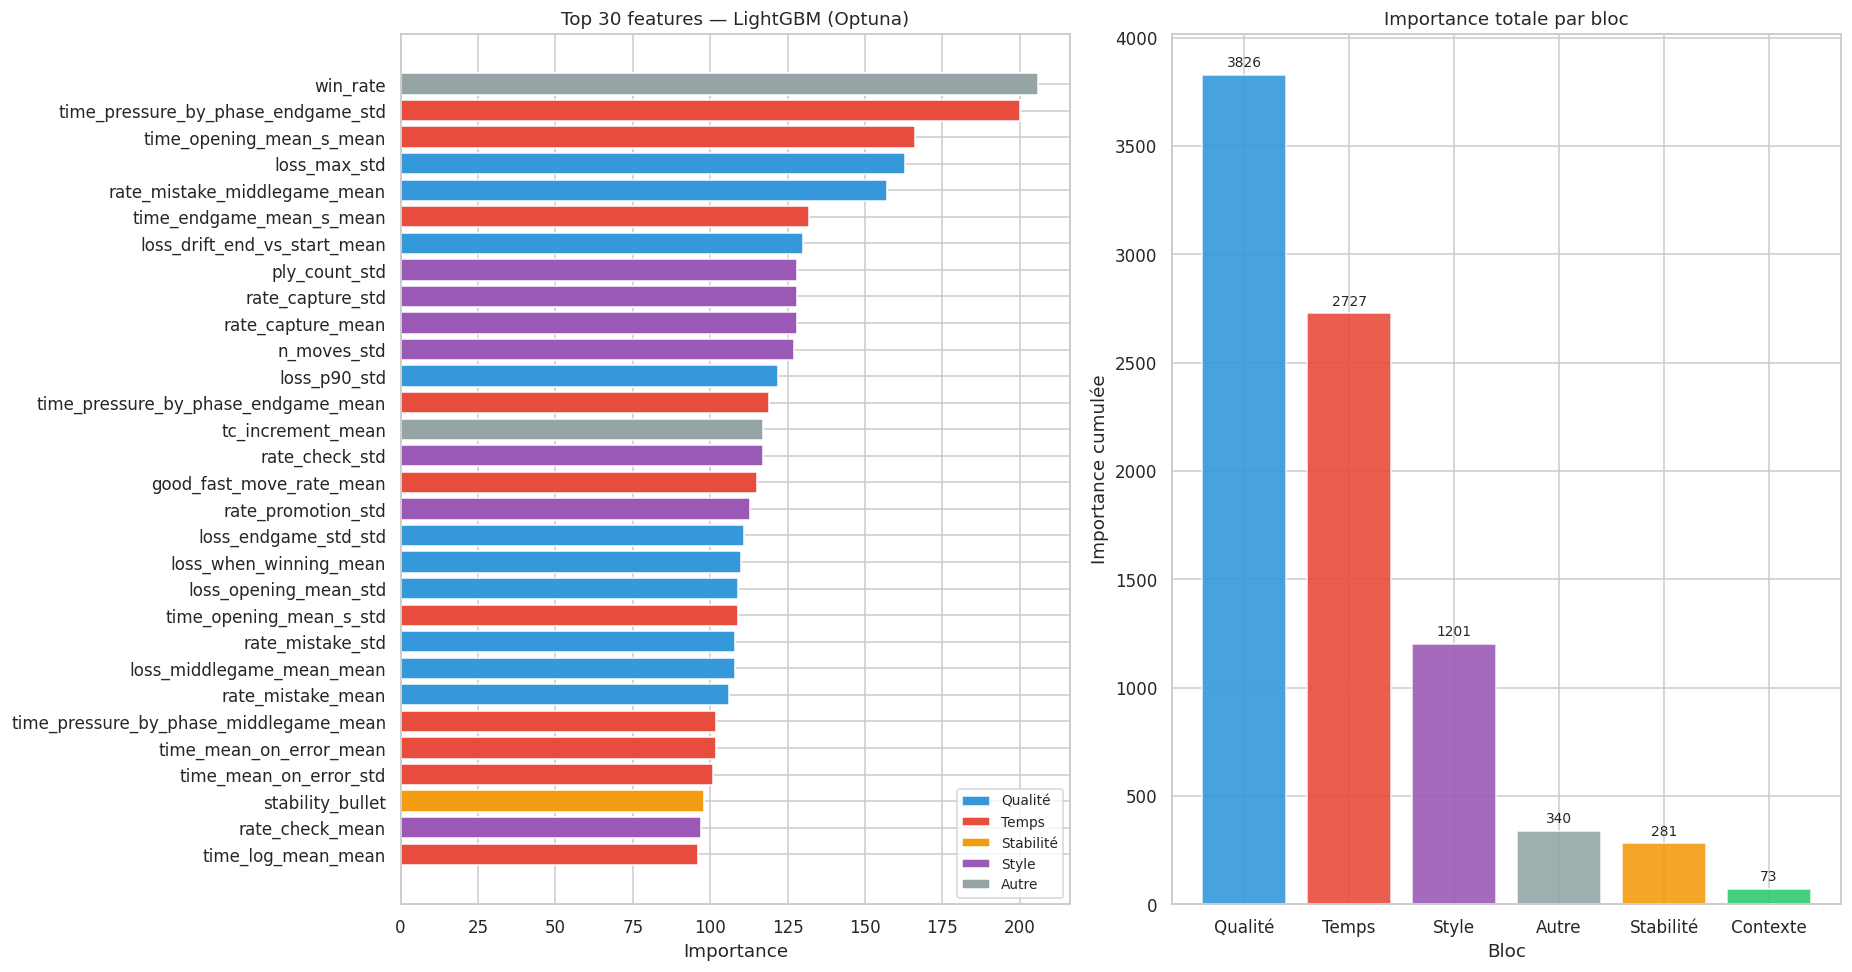


=== Importance par bloc ===
bloc
Qualité      3826
Temps        2727
Style        1201
Autre         340
Stabilité     281
Contexte       73

=== Top 15 features LightGBM ===
                            feature    bloc  importance
                           win_rate   Autre         206
 time_pressure_by_phase_endgame_std   Temps         200
           time_opening_mean_s_mean   Temps         166
                       loss_max_std Qualité         163
       rate_mistake_middlegame_mean Qualité         157
           time_endgame_mean_s_mean   Temps         132
       loss_drift_end_vs_start_mean Qualité         130
                   rate_capture_std   Style         128
                  rate_capture_mean   Style         128
                      ply_count_std   Style         128
                        n_moves_std   Style         127
                       loss_p90_std Qualité         122
time_pressure_by_phase_endgame_mean   Temps         119
                     rate_check_std   St

In [19]:
# Choisir le meilleur modèle LightGBM disponible
lgb_result = next(
    (r for r in results_v3 if r['name'] == 'LightGBM (Optuna)'),
    next((r for r in results_v3 if 'LightGBM' in r['name']), None)
)

if lgb_result is None:
    print("⚠ Aucun modèle LightGBM disponible")
else:
    lgb_model = lgb_result['model'].named_steps['m']
    imp_lgb   = pd.Series(lgb_model.feature_importances_, index=feature_cols)
    imp_lgb   = imp_lgb.sort_values(ascending=False)

    # ── Tagger chaque feature par bloc ──────────────────────────────────────────────────
    def tag_bloc(name):
        if any(k in name for k in ['time', 'clock', 'low_time', 'fast_move', 'pressure']):
            return 'Temps'
        if any(k in name for k in ['loss', 'rate_good', 'rate_error', 'rate_blunder',
                                    'rate_mistake', 'rate_inaccuracy', 'n_blunders',
                                    'n_mistakes', 'rate_loss']):
            return 'Qualité'
        if any(k in name for k in ['when_', 'opening', 'middlegame', 'endgame',
                                    'winning', 'equal', 'losing']):
            return 'Contexte'
        if any(k in name for k in ['variance', 'stability', 'drift', 'gap',
                                    'drop', 'cv', 'prop_games']):
            return 'Stabilité'
        if any(k in name for k in ['capture', 'check', 'castle', 'promotion',
                                    'eco', 'speed', 'n_moves', 'ply']):
            return 'Style'
        return 'Autre'

    imp_df = imp_lgb.reset_index()
    imp_df.columns = ['feature', 'importance']
    imp_df['bloc'] = imp_df['feature'].apply(tag_bloc)

    # ── Graphique top 30 coloré par bloc + importance agrégée ────────────────────────
    palette_bloc = {
        'Qualité':   '#3498db',
        'Temps':     '#e74c3c',
        'Contexte':  '#2ecc71',
        'Stabilité': '#f39c12',
        'Style':     '#9b59b6',
        'Autre':     '#95a5a6',
    }

    top30  = imp_df.head(30).sort_values('importance')
    colors = top30['bloc'].map(palette_bloc)

    fig, axes = plt.subplots(1, 2, figsize=(17, 9))

    # Barplot top 30
    axes[0].barh(top30['feature'], top30['importance'], color=colors, edgecolor='white')
    axes[0].set_title(f'Top 30 features — {lgb_result["name"]}', fontsize=12)
    axes[0].set_xlabel('Importance')
    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=v, label=k)
                  for k, v in palette_bloc.items() if k in top30['bloc'].values]
    axes[0].legend(handles=legend_els, loc='lower right', fontsize=9)

    # Importance agrégée par bloc
    bloc_imp    = imp_df.groupby('bloc')['importance'].sum().sort_values(ascending=False)
    bloc_colors = [palette_bloc.get(b, '#95a5a6') for b in bloc_imp.index]
    axes[1].bar(bloc_imp.index, bloc_imp.values, color=bloc_colors, edgecolor='white', alpha=0.9)
    axes[1].set_title('Importance totale par bloc', fontsize=12)
    axes[1].set_xlabel('Bloc')
    axes[1].set_ylabel('Importance cumulée')
    for i, (bloc, val) in enumerate(bloc_imp.items()):
        axes[1].text(i, val + bloc_imp.max() * 0.01,
                     f'{val:.0f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # ── Tableaux texte ────────────────────────────────────────────────────────────────────────────────
    print("\n=== Importance par bloc ===")
    print(bloc_imp.round(1).to_string())

    print("\n=== Top 15 features LightGBM ===")
    print(imp_df.head(15)[['feature', 'bloc', 'importance']].to_string(index=False))

    # ── Confirmation inter-modèles ───────────────────────────────────────────────────────────────────────
    rf_result = next((r for r in results_v3 if 'Random' in r['name']), None)
    if rf_result:
        rf_model  = rf_result['model'].named_steps['m']
        imp_rf    = pd.Series(rf_model.feature_importances_, index=feature_cols)
        top10_lgb = set(imp_lgb.head(10).index)
        top10_rf  = set(imp_rf.sort_values(ascending=False).head(10).index)
        overlap   = top10_lgb & top10_rf
        print(f"\n=== Confirmation inter-modèles (top 10) ===")
        print(f"  Features en commun LightGBM ∩ RandomForest : {len(overlap)}/10")
        for feat in sorted(overlap):
            print(f"    [{tag_bloc(feat):10s}] {feat}")
        print()
        if len(overlap) >= 5:
            print("  → Signal robuste : les mêmes blocs dominent dans les deux modèles.")
        else:
            print("  → Signal mixte : les modèles mettent l'accent sur des features différentes.")


---
## 6d. Tableau Final Comparaison Tous Modèles


  CLASSEMENT FINAL — TOUS MODÈLES
           Modèle     MAE    RMSE     R²
LightGBM (Optuna) 124.994 160.847  0.764
LightGBM (défaut) 128.564 166.773  0.747
         CatBoost 131.248 170.147  0.736
 Ridge (baseline) 136.028 184.783  0.689
          XGBoost 136.695 175.344  0.720
     RandomForest 141.149 181.225  0.701
              MLP 270.025 378.583 -0.305


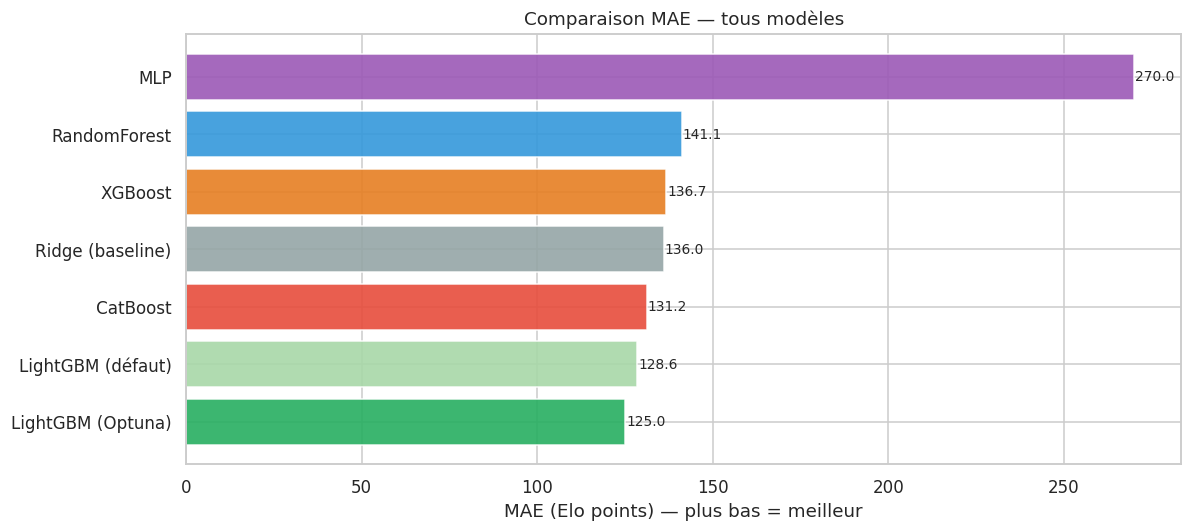

In [20]:
df_final = pd.DataFrame(
    [{'Modèle': r['name'], 'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R2']}
     for r in results_v3]
).sort_values('MAE').reset_index(drop=True)

print("=" * 60)
print("  CLASSEMENT FINAL — TOUS MODÈLES")
print("=" * 60)
print(df_final.to_string(index=False))

# Graphique comparatif
color_map = {
    'Ridge (baseline)':   '#95a5a6',
    'RandomForest':       '#3498db',
    'XGBoost':            '#e67e22',
    'LightGBM (défaut)':  '#a8d8a8',
    'LightGBM (Optuna)':  '#27ae60',
    'CatBoost':           '#e74c3c',
    'MLP':                '#9b59b6',
}
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [color_map.get(n, '#bdc3c7') for n in df_final['Modèle']]
bars = ax.barh(df_final['Modèle'], df_final['MAE'],
               color=bar_colors, edgecolor='white', alpha=0.9)
ax.set_xlabel('MAE (Elo points) — plus bas = meilleur')
ax.set_title('Comparaison MAE — tous modèles', fontsize=12)
for bar, val in zip(bars, df_final['MAE']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


---
## 7. Évaluation Visuelle

Meilleur modèle V3 : LightGBM (Optuna) (MAE=125.0)


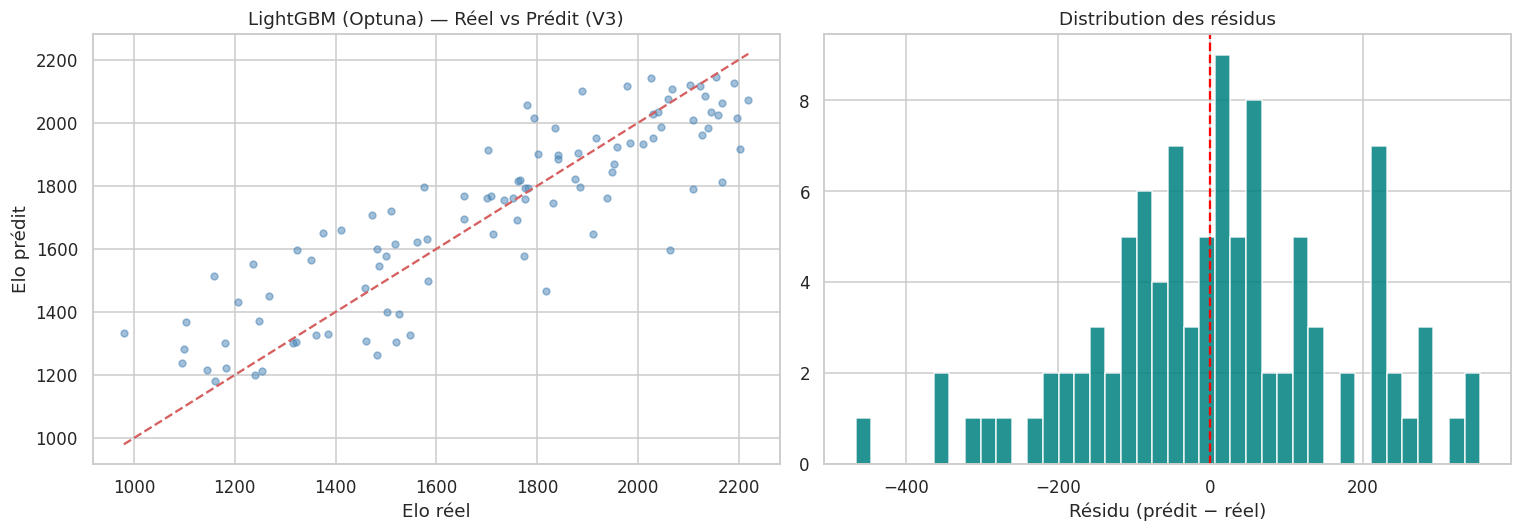

In [21]:
best_v3 = min(results_v3, key=lambda r: r['MAE'])
print(f"Meilleur modèle V3 : {best_v3['name']} (MAE={best_v3['MAE']:.1f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_v3['y_pred'], alpha=0.5, s=20, color='steelblue')
mn, mx = min(y_test.min(), best_v3['y_pred'].min()), max(y_test.max(), best_v3['y_pred'].max())
axes[0].plot([mn, mx], [mn, mx], '--r', lw=1.5)
axes[0].set_xlabel('Elo réel'); axes[0].set_ylabel('Elo prédit')
axes[0].set_title(f'{best_v3["name"]} — Réel vs Prédit (V3)')

residuals = best_v3['y_pred'] - y_test
axes[1].hist(residuals, bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Résidu (prédit − réel)')
axes[1].set_title('Distribution des résidus')

plt.tight_layout(); plt.show()

In [22]:
def plot_importances(model_result, feature_cols, top_n=25, color='steelblue'):
    pipeline = model_result['model']

    # récupérer le dernier estimateur du pipeline
    if hasattr(pipeline, "steps"):
        final_model = pipeline.steps[-1][1]
    else:
        final_model = pipeline

    if not hasattr(final_model, 'feature_importances_'):
        print(f"{model_result['name']} — pas de feature_importances_")
        return None

    importances = pd.Series(
        final_model.feature_importances_, index=feature_cols
    ).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 7))
    importances.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f"Top {top_n} features — {model_result['name']}", fontsize=12)

    plt.tight_layout()
    plt.show()

    print(importances.head(15).round(4).to_string())
    return importances

---
## 11. Sauvegarde

In [52]:
# ── Sauvegarde des datasets finaux ────────────────────────────────────────────

# 1. Features game-level enrichies
game_rich.to_csv('game_level_features_v4.csv', index=False)
print(f"✓ game_level_features_v4.csv       — {game_rich.shape}")

# 2. Dataset player-level (sans clustering)
dataset.to_csv('player_level_features_v3.csv', index=False)
print(f"✓ player_level_features_v3.csv     — {dataset.shape}")

# 3. Meilleur modèle LightGBM — infos utiles pour la V4+
import json

# Sauvegarder les meilleurs hyperparamètres Optuna si disponibles
if 'study' in dir() and study is not None:
    best_params = study.best_params
    with open('lgb_best_params.json', 'w') as f:
        json.dump(best_params, f, indent=2)
    print(f"✓ lgb_best_params.json             — {best_params}")
else:
    print("⚠ study non disponible — lgb_best_params.json non sauvegardé")

# 4. Résumé des features utilisées
with open('feature_cols_v4.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f"✓ feature_cols_v4.json             — {len(feature_cols)} features")

print("\n✓ Tous les fichiers sauvegardés.")
print("  → Ces fichiers sont le point de départ du notebook V4+")

✓ game_level_features_v4.csv       — (25848, 79)
✓ player_level_features_v3.csv     — (941, 148)
✓ lgb_best_params.json             — {'n_estimators': 974, 'learning_rate': 0.057489180054056295, 'num_leaves': 48, 'max_depth': 8, 'min_child_samples': 32, 'subsample': 0.8870983927079958, 'colsample_bytree': 0.9244368876713575, 'reg_alpha': 0.12479240560814463, 'reg_lambda': 0.4633737957908787}
✓ feature_cols_v4.json             — 144 features

✓ Tous les fichiers sauvegardés.
  → Ces fichiers sont le point de départ du notebook V4+
